In [167]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.seasonal import MSTL
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import LinearRegression, QuantileRegressor

# Context


## Load data


In [11]:
my_path = "cfm_dim_test.parquet"
df = pd.read_parquet(my_path)

df = df[['value_date', 'utilisation_date', 'individual_code', 'uuid', 'value']].copy()

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45152 entries, 0 to 45151
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   value_date        45152 non-null  datetime64[ns]
 1   utilisation_date  45152 non-null  datetime64[ns]
 2   individual_code   45152 non-null  object        
 3   uuid              45152 non-null  object        
 4   value             45152 non-null  float64       
dtypes: datetime64[ns](2), float64(1), object(2)
memory usage: 1.7+ MB


In [13]:
df.head()

,value_date,utilisation_date,individual_code,uuid,value
0,2013-12-30,2014-01-06,S2,7da648ca-4808-4111-a56e-377aa7e0b54d,6.196791e+05
1,2013-12-29,2014-01-12,S3,b5061620-31a7-4350-a9f2-b98c47e8cdce,1.110781e+07
2,2013-12-20,2014-01-03,S1,1503284c-a423-4c81-9894-207e553017b0,5.607246e+05
3,2013-12-25,2014-01-01,S2,adcbc78a-df64-4cc2-a8d4-01fb2679a729,3.962005e+05
4,2013-12-24,2014-01-07,S1,489e3845-d68a-4779-ba5e-45bc18b2ec2f,4.133021e+05


## Data description

The dataset contains dollars spent on 3 differents products identified by their `individual_code`. Each transaction is identified by:

- `uuid` a unique identifier of the row;
- `value` the amount in dollar;
- `value_date` a date at which the transaction was done;
- `utilisation_date` a date at which the transaction is made available to you.


## Predict

The goal is to build forecasting models for each `individual_code` that can predict which `value` will be made available to you 7 days ahead (`utilisation_date`). The sample will be split the following way:

- Train sample: from 2014-01 to 2018-12;
- Test sample: from 2019-01 to 2019-12

## Discussion

As often the journey is more important than the destination: having a full working model is not an end in itself, we expect more a structured data analysis and methodical approach.

- Understanding and describing the target and the features: show informative plots, information that will help to build robust machine learning model.

- Taking into account production constraints (null values and outliers management, future information contamination etc...)

- Defining an evaluation metric and a benchmark.


# 1. Data Exploration

In [32]:
df.head()

,value_date,utilisation_date,individual_code,uuid,value
0,2013-12-30,2014-01-06,S2,7da648ca-4808-4111-a56e-377aa7e0b54d,6.196791e+05
1,2013-12-29,2014-01-12,S3,b5061620-31a7-4350-a9f2-b98c47e8cdce,1.110781e+07
2,2013-12-20,2014-01-03,S1,1503284c-a423-4c81-9894-207e553017b0,5.607246e+05
3,2013-12-25,2014-01-01,S2,adcbc78a-df64-4cc2-a8d4-01fb2679a729,3.962005e+05
4,2013-12-24,2014-01-07,S1,489e3845-d68a-4779-ba5e-45bc18b2ec2f,4.133021e+05


## Number of UUID per Individual Codes

In [18]:
df.groupby(['individual_code'])['uuid'].count()

individual_code
S1    14517
S2    14881
S3    15754
Name: uuid, dtype: int64

In [22]:
df.groupby(['individual_code'])['value'].apply(lambda x: x.isnull().sum())

individual_code
S1    0
S2    0
S3    0
Name: value, dtype: int64

value_date: The moment the transaction physically occurred.

utilisation_date: The moment the data (the value) actually becomes "available to me"

In [37]:
s1_ts = df[df['individual_code'] == 'S1'].copy().pivot_table(index='utilisation_date', columns='uuid', values='value')
s2_ts = df[df['individual_code'] == 'S2'].copy().pivot_table(index='utilisation_date', columns='uuid', values='value')
s3_ts = df[df['individual_code'] == 'S3'].copy().pivot_table(index='utilisation_date', columns='uuid', values='value')

In [38]:
s1_ts.isnull().sum(axis=0) / s1_ts.shape[0]

uuid
00008129-76db-4247-93c2-d7d385e672b6    0.999726
0002952d-07e6-411e-945a-8035481a990e    0.999726
0003276e-977a-4f75-a833-58f6f4e9b4a5    0.999726
0004e91a-b03d-4073-b2e3-c34f4d99c4db    0.999726
00054e8f-a928-415a-90fd-0d4ff380b15a    0.999726
                                          ...   
ffec6d57-4656-4a5c-bc4d-38972d2a6244    0.999726
ffee60d5-76c9-4a36-84f7-9141d5659643    0.999726
fffa9664-baf3-4b99-8f1b-07b2ef1e4e38    0.999726
fffe4e92-4b6f-4d52-b131-193462bf076d    0.999726
ffff1d4f-1fea-48db-9a53-43c79106e615    0.999726
Length: 14517, dtype: float64

In [39]:
s2_ts.isnull().sum(axis=0) / s2_ts.shape[0]

uuid
000ea76f-9bde-4f99-929c-b4881382f44d    0.999726
0011d850-de89-4087-9d2e-5e09fdd88d8e    0.999726
001c2148-a98b-430c-8ed2-e9f78cd43c86    0.999726
00234e4b-9f74-40e9-905d-905b488590c2    0.999726
0023e1e1-ded1-47c3-b750-d848adcc1f34    0.999726
                                          ...   
ffedb218-f8a8-4181-a886-b37d3b86e972    0.999726
fff634bd-7fe2-4fba-9a22-c3f1d0b8bdff    0.999726
fff69ac0-a9cd-46d6-8c87-29d7d339f6e1    0.999726
fff77ec3-1f1e-4ef9-8c12-c63e1eeb44ad    0.999726
fffa1cbd-c87b-408c-992e-a30d57324105    0.999726
Length: 14881, dtype: float64

In [40]:
s3_ts.isnull().sum(axis=0) / s3_ts.shape[0]

uuid
0000858e-35f9-47c1-82d9-020de7c2f725    0.999726
00028479-e258-4152-a865-4fa34f7e7c55    0.999726
000357bc-5c21-46c5-aa29-8fb785ccb96f    0.999726
00040c49-2b04-4191-9ba3-232633eb2e1f    0.999726
000790c2-334b-41b0-9eaf-4c4c9c125b18    0.999726
                                          ...   
ffe797e7-6e4b-414d-b750-2fb176860ad5    0.999726
ffea3fcd-f0b1-49f0-a79d-d47a139f9d2f    0.999726
fff3c09a-70e0-4253-85a1-14c87481f366    0.999726
fff77221-9138-4c0b-9e99-b909246b0cbc    0.999726
fff7baf7-2dd6-4967-b3c8-af6cb61250fe    0.999726
Length: 15754, dtype: float64

In [48]:
(~s1_ts.isnull()).sum(axis=0).sort_values()

uuid
00008129-76db-4247-93c2-d7d385e672b6    1
aaf9c672-e774-42b2-a7de-96e8ecc6fc05    1
ab021490-06ae-4102-b5e7-210b1be4d1b4    1
ab028a89-3434-4502-9ebe-964b1a359ba8    1
ab05c470-1995-4aef-86df-4251222e5c94    1
                                       ..
56348713-134b-404a-9cdc-04e7ade2b4a3    1
5637f23b-46b0-4c70-b370-1a176060693f    1
563af987-6071-4439-b2b0-6844f3a73347    1
55ae872b-ba15-4d97-b929-18563fcc4212    1
ffff1d4f-1fea-48db-9a53-43c79106e615    1
Length: 14517, dtype: int64

In [49]:
(~s2_ts.isnull()).sum(axis=0).sort_values()

uuid
000ea76f-9bde-4f99-929c-b4881382f44d    1
abf91661-add4-4940-8ce4-814899091c10    1
ac001351-f3b4-43b4-9937-8549a3e376ab    1
ac01d2a0-8c84-436b-83a2-f5e608096b0a    1
ac0dfc68-02e3-4711-87c5-e25f1c48d449    1
                                       ..
56b52776-2257-49b1-af5e-16843877297d    1
56ba11ef-c7e5-4be0-a999-b315b1cdc7f6    1
56c13f07-525d-4aa6-b714-c12254d0c323    1
569669a9-26ff-4be6-a8c7-8d7cd75eacc5    1
fffa1cbd-c87b-408c-992e-a30d57324105    1
Length: 14881, dtype: int64

In [50]:
(~s3_ts.isnull()).sum(axis=0).sort_values()

uuid
0000858e-35f9-47c1-82d9-020de7c2f725    1
ab015606-3c88-4c96-a95d-41b6a4191083    1
ab039651-b1da-498c-a85c-778bd00756c0    1
ab05d88a-f883-4af8-bcd9-2b45c0cc92ac    1
ab08339a-fa2e-47a2-abb4-4508982909b2    1
                                       ..
56431b0a-40bb-40ed-9fb3-6479d6661ef2    1
56444320-037e-473a-8166-6ba2fa45d98a    1
56473eb7-8a3c-4cd5-a6f5-6aeeaaf52eee    1
564da4e5-8b12-4b38-922c-d5737414e995    1
fff7baf7-2dd6-4967-b3c8-af6cb61250fe    1
Length: 15754, dtype: int64

## Missing Values

In [127]:
s1_ts = df[df['individual_code'] == 'S1'].groupby(['utilisation_date', 'individual_code'])[['value']].sum().pivot_table(index='utilisation_date', columns='individual_code', values='value').resample('D').last()
s2_ts = df[df['individual_code'] == 'S2'].groupby(['utilisation_date', 'individual_code'])[['value']].sum().pivot_table(index='utilisation_date', columns='individual_code', values='value').resample('D').last()
s3_ts = df[df['individual_code'] == 'S3'].groupby(['utilisation_date', 'individual_code'])[['value']].sum().pivot_table(index='utilisation_date', columns='individual_code', values='value').resample('D').last()

In [128]:
s1_ts.isnull().sum(axis=0) / s1_ts.shape[0]

individual_code
S1    0.0
dtype: float64

In [129]:
s2_ts.isnull().sum(axis=0) / s2_ts.shape[0]

individual_code
S2    0.0
dtype: float64

In [130]:
s3_ts.isnull().sum(axis=0) / s3_ts.shape[0]

individual_code
S3    0.001095
dtype: float64

In [131]:
s3_ts.isnull().sum(axis=0)

individual_code
S3    4
dtype: int64

In [132]:
# # has missing values on less than 1% of the days. i expanded the missing dates and filled with zero to represent no sales.
# s3_ts = df[df['individual_code'] == 'S3'].groupby(['utilisation_date', 'individual_code'])[['value']].sum().pivot_table(index='utilisation_date', columns='individual_code', values='value').resample('D').last().fillna(0.00001)
# filling missing dates with tiny values messes with log transformation everything afterwards. so we will apply forward fill instead.
s3_ts = df[df['individual_code'] == 'S3'].groupby(['utilisation_date', 'individual_code'])[['value']].sum().pivot_table(index='utilisation_date', columns='individual_code', values='value').resample('D').last().ffill()

In [133]:
s3_ts.isnull().sum(axis=0)

individual_code
S3    0
dtype: int64

## Train/Validation Split

In [172]:
# - Train sample: from 2014-01 to 2018-12;
# - Test sample: from 2019-01 to 2019-12

train_s1_ts = s1_ts.loc['2014-01':'2018-12']
test_s1_ts = s1_ts.loc['2019-01':'2019-12']

train_s2_ts = s2_ts.loc['2014-01':'2018-12']
test_s2_ts = s2_ts.loc['2019-01':'2019-12']

train_s3_ts = s3_ts.loc['2014-01':'2018-12']
test_s3_ts = s3_ts.loc['2019-01':'2019-12']

train_tss = [train_s1_ts, train_s2_ts, train_s3_ts]
test_tss = [test_s1_ts, test_s2_ts, test_s3_ts]

## Seasonality and Trend

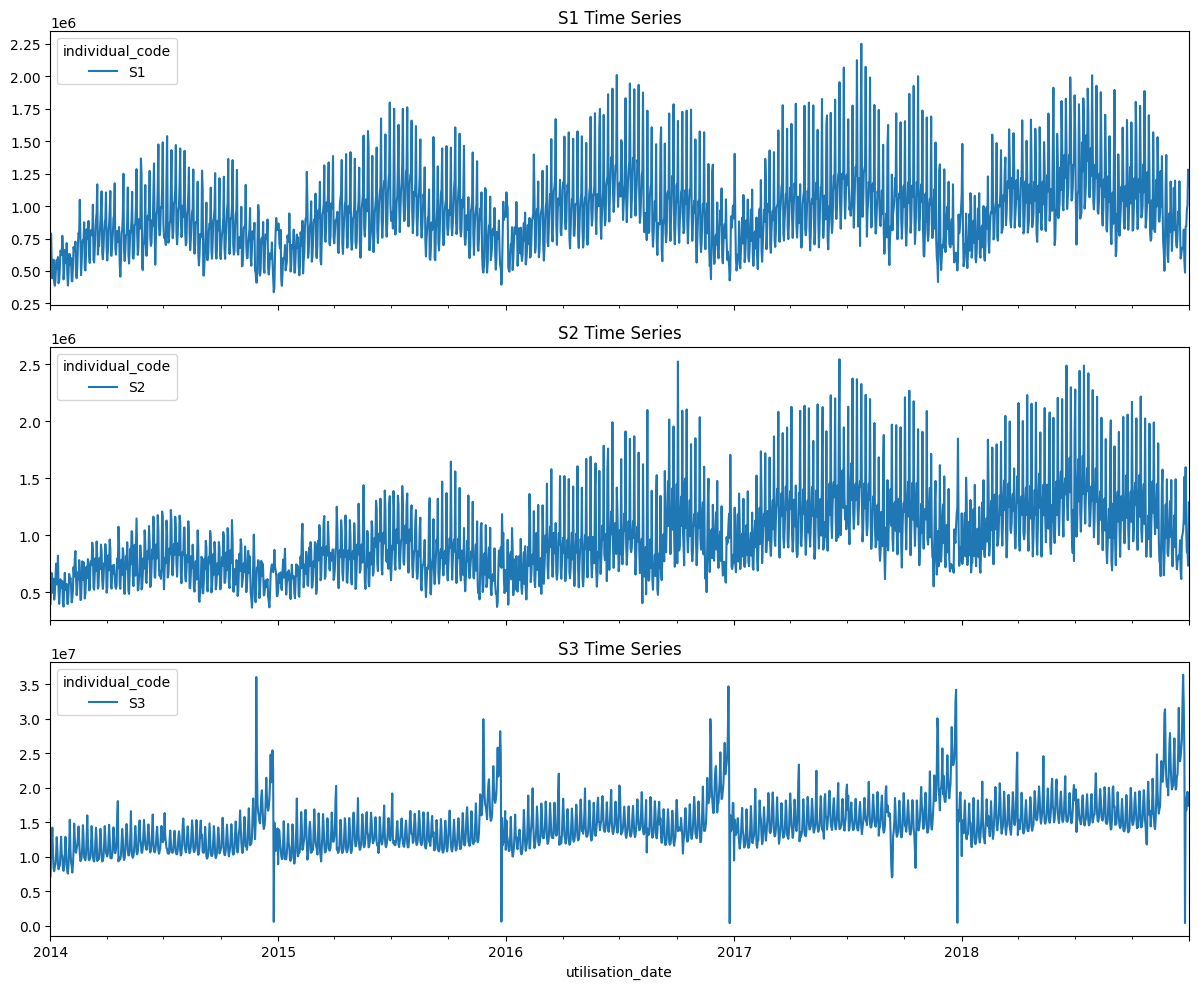

In [175]:
fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

train_s1_ts = train_tss[0]
train_s2_ts = train_tss[1]
train_s3_ts = train_tss[2]

train_s1_ts.plot(ax=ax[0], title='S1 Time Series')
train_s2_ts.plot(ax=ax[1], title='S2 Time Series')
train_s3_ts.plot(ax=ax[2], title='S3 Time Series')
plt.tight_layout()
plt.show()

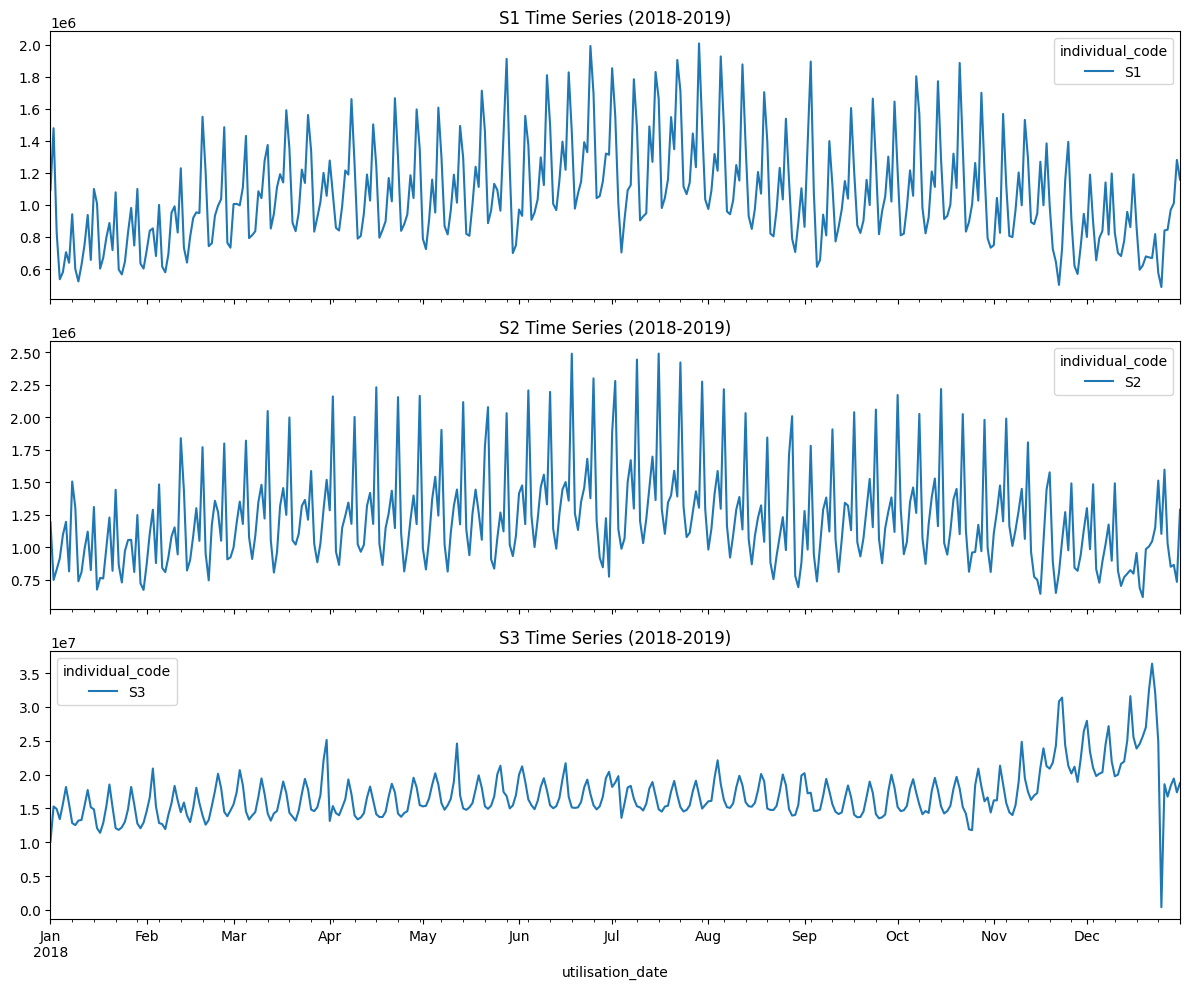

In [176]:
s1_ts_2019 = train_s1_ts[(train_s1_ts.index.year >= 2018) & (train_s1_ts.index.year <= 2019)]
s2_ts_2019 = train_s2_ts[(train_s2_ts.index.year >= 2018) & (train_s2_ts.index.year <= 2019)]
s3_ts_2019 = train_s3_ts[(train_s3_ts.index.year >= 2018) & (train_s3_ts.index.year <= 2019)]

fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

s1_ts_2019.plot(ax=ax[0], title='S1 Time Series (2018-2019)')
s2_ts_2019.plot(ax=ax[1], title='S2 Time Series (2018-2019)')
s3_ts_2019.plot(ax=ax[2], title='S3 Time Series (2018-2019)')

plt.tight_layout()
plt.show()

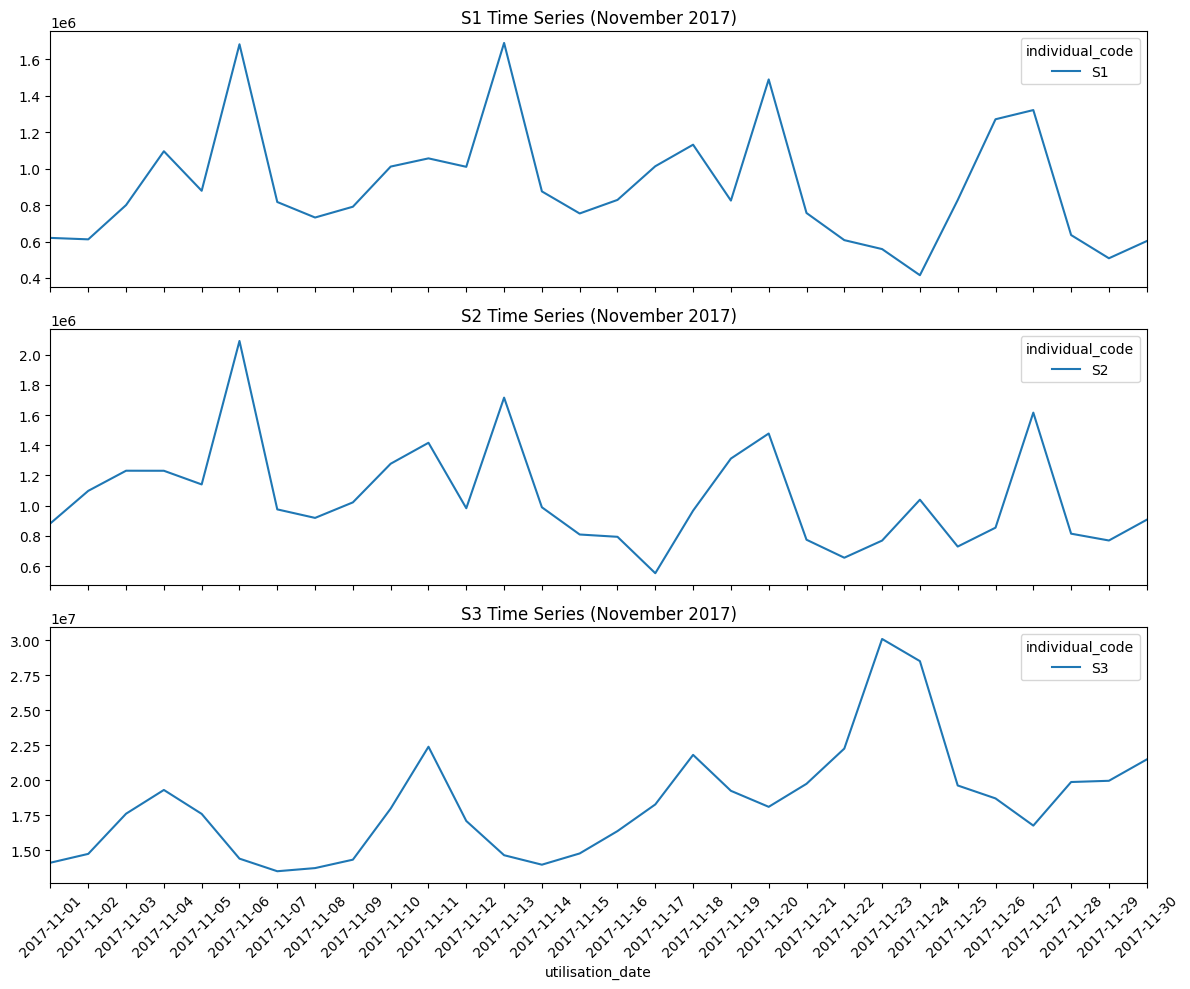

In [178]:
s1_ts_2019 = train_s1_ts[(train_s1_ts.index.year == 2017) & (train_s1_ts.index.month == 11)]
s2_ts_2019 = train_s2_ts[(train_s2_ts.index.year == 2017) & (train_s2_ts.index.month == 11)]
s3_ts_2019 = train_s3_ts[(train_s3_ts.index.year == 2017) & (train_s3_ts.index.month == 11)]

fig, ax = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

s1_ts_2019.plot(ax=ax[0], title='S1 Time Series (November 2017)')
s2_ts_2019.plot(ax=ax[1], title='S2 Time Series (November 2017)')
s3_ts_2019.plot(ax=ax[2], title='S3 Time Series (November 2017)')

ax[2].set_xticks(s3_ts_2019.index)
ax[2].set_xticklabels(s3_ts_2019.index.strftime('%Y-%m-%d'), rotation=45)

plt.tight_layout()
plt.show()

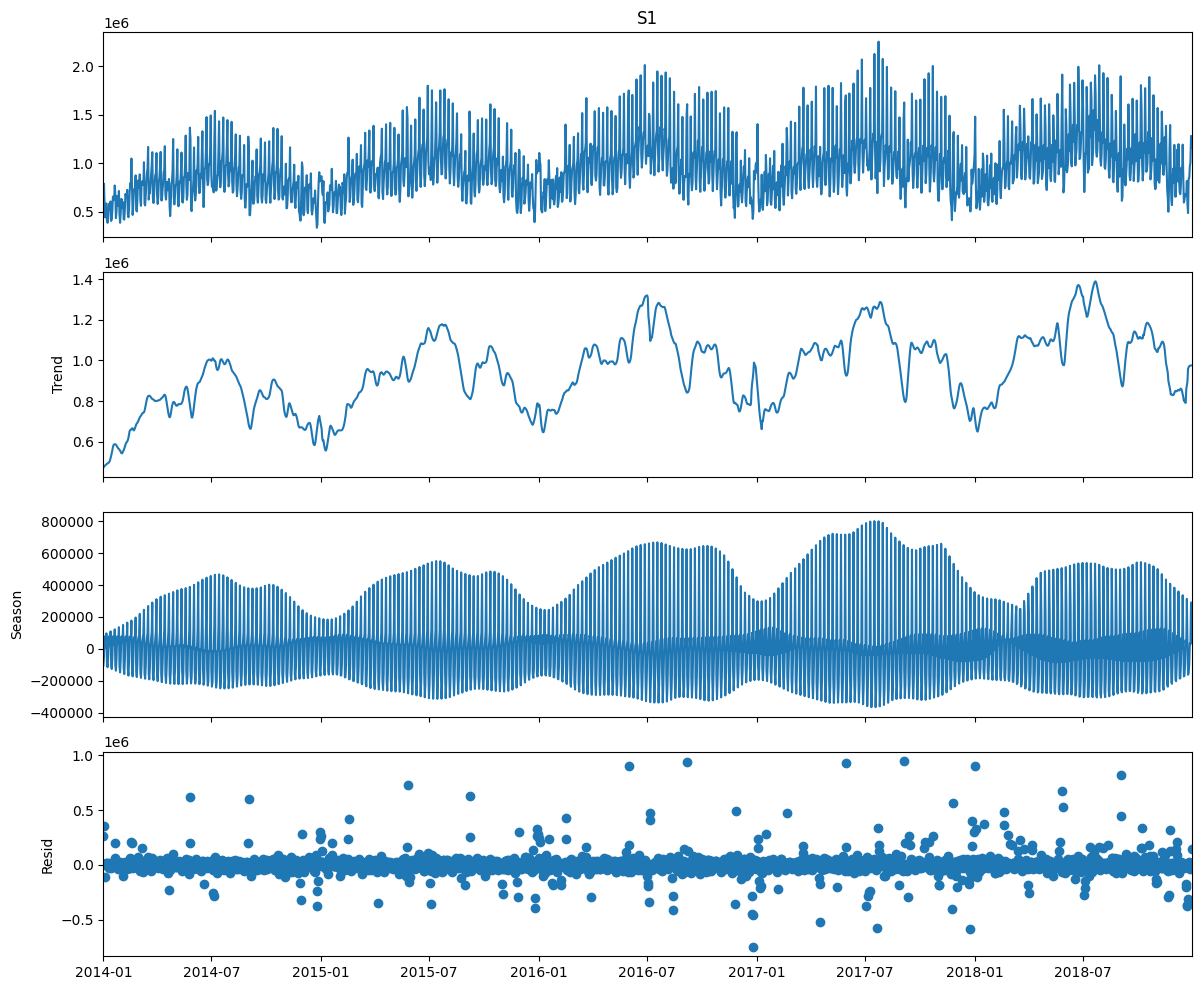

In [179]:
series = train_s1_ts['S1']
series.index = pd.to_datetime(series.index)
series = series.asfreq('D') 

# period=7 captures the weekly seasonality (Day of Week)
stl = STL(series, period=7, seasonal=13, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

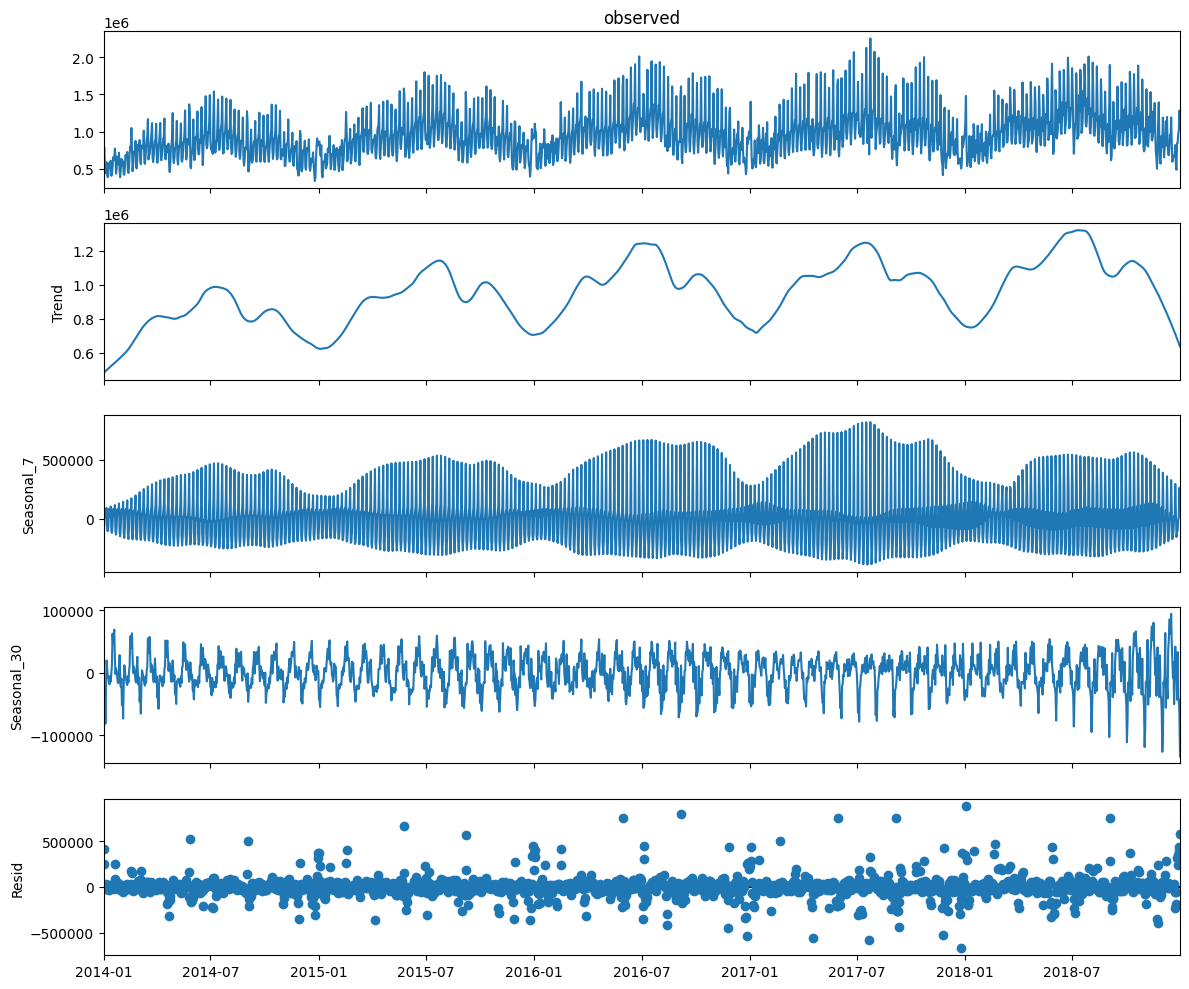

In [180]:
series = train_s1_ts['S1']
series.index = pd.to_datetime(series.index)
series = series.asfreq('D') 

res = MSTL(
    series,                                         # 
    periods=(7, 30),                                # Seasonal periods: weekly and monthly
    stl_kwargs={"seasonal": 31, "robust": True}     #
).fit()

fig = res.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

### S1 Last

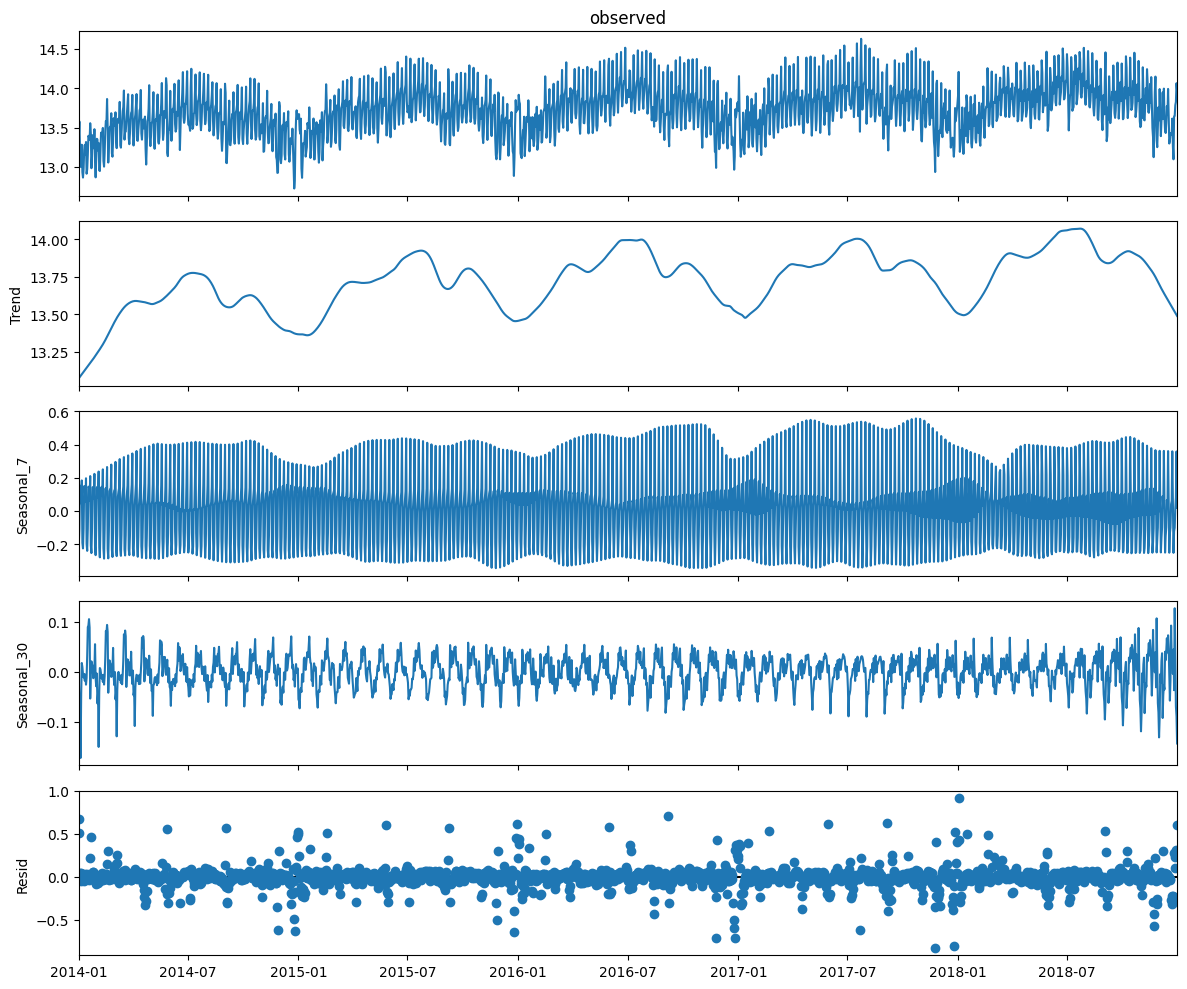

In [181]:
log_s1_ts = np.log(train_s1_ts.copy())

series = log_s1_ts['S1']
series.index = pd.to_datetime(series.index)
series = series.asfreq('D') 

res = MSTL(
    series,                                         # 
    periods=(7, 30),                                # Seasonal periods: weekly and monthly
    stl_kwargs={"seasonal": 31, "robust": True}     #
).fit()

fig = res.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

### S2 Last

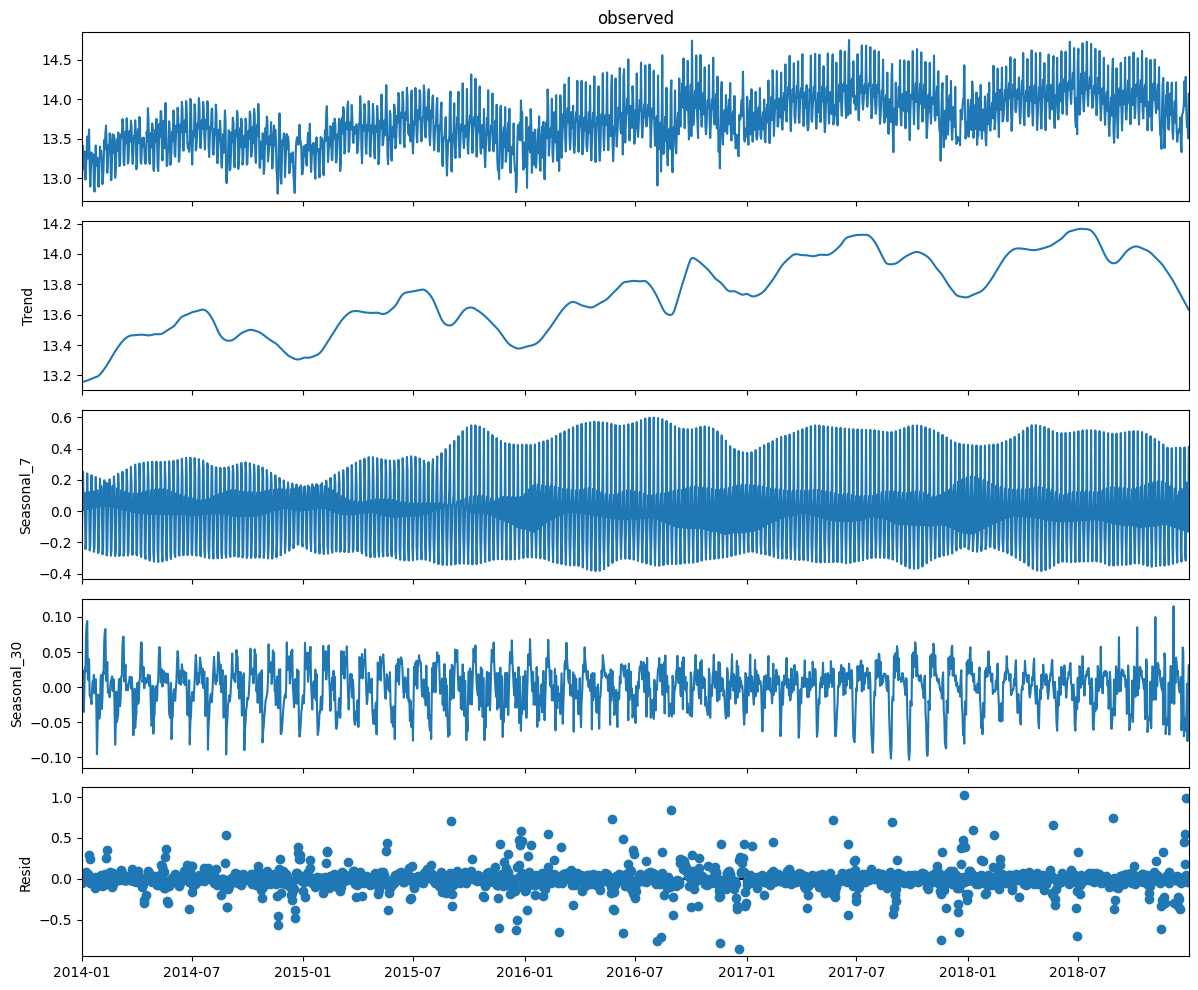

In [182]:
log_s2_ts = np.log(train_s2_ts.copy())

series = log_s2_ts['S2']
series.index = pd.to_datetime(series.index)
series = series.asfreq('D') 

res = MSTL(
    series,                                         # 
    periods=(7, 30),                                # Seasonal periods: weekly and monthly
    stl_kwargs={"seasonal": 31, "robust": True}     #
).fit()

fig = res.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

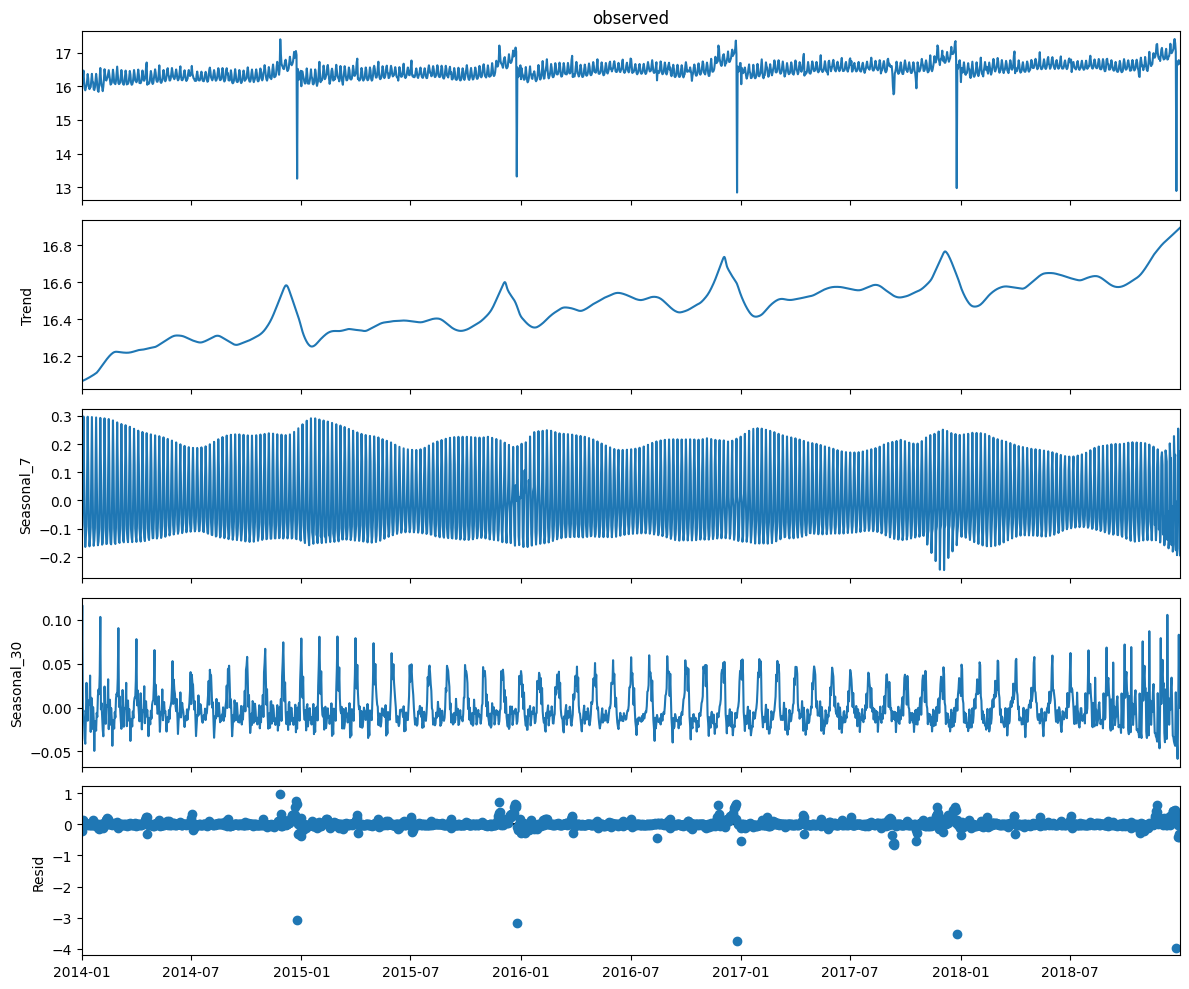

In [183]:
log_s3_ts = np.log(train_s3_ts.copy())

series = log_s3_ts['S3']
series.index = pd.to_datetime(series.index)
series = series.asfreq('D') 

res = MSTL(
    series,                                         # 
    periods=(7, 30),                                # Seasonal periods: weekly and monthly
    stl_kwargs={"seasonal": 31, "robust": True}     #
).fit()

fig = res.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

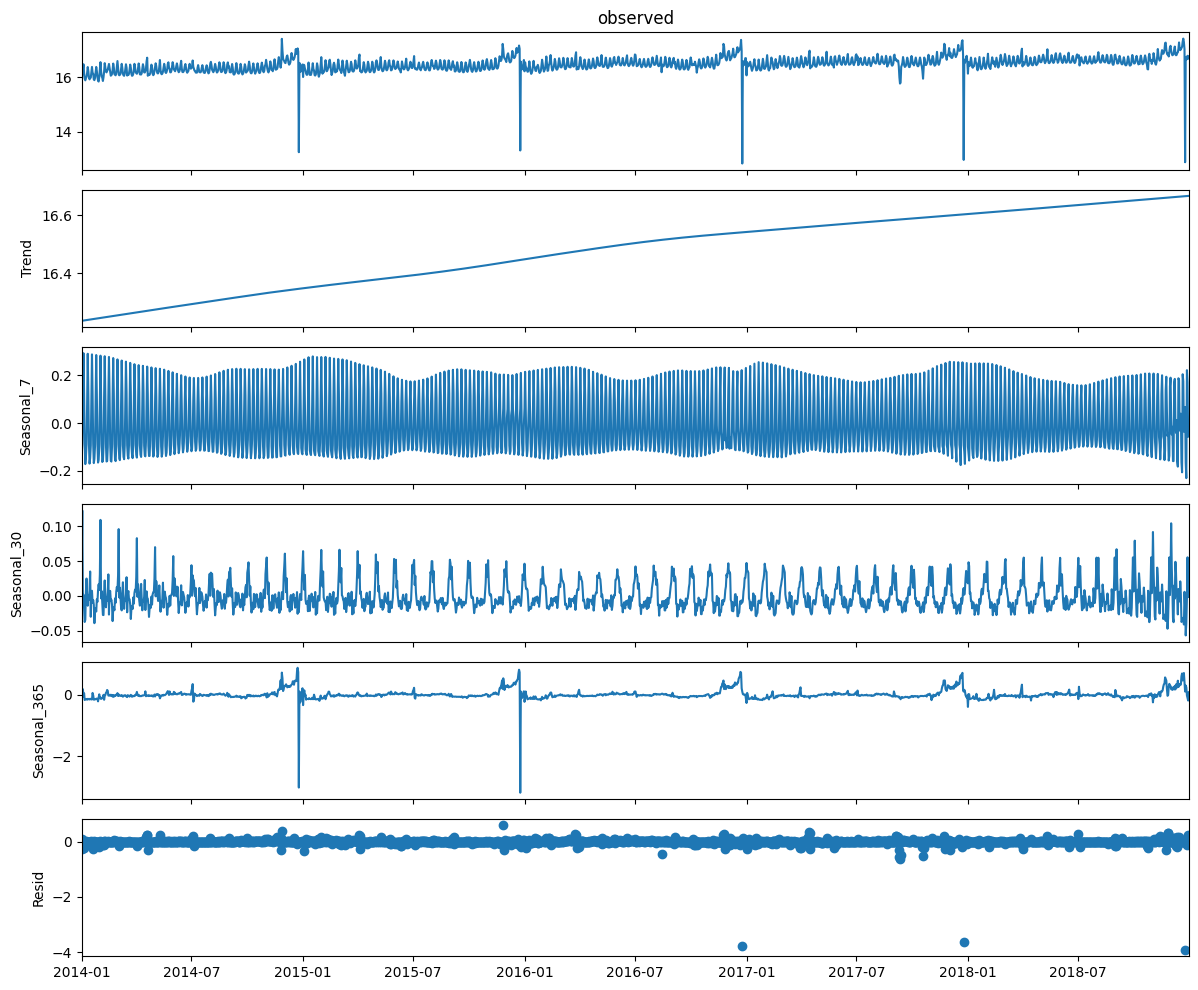

In [184]:
log_s3_ts = np.log(train_s3_ts.copy())

series = log_s3_ts['S3']
series.index = pd.to_datetime(series.index)
series = series.asfreq('D') 

res = MSTL(
    series,                                         
    periods=(7, 30, 365),                           # Seasonal periods: weekly and monthly
    stl_kwargs={
        "seasonal": 31, 
        "robust": True
        }
).fit()

fig = res.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

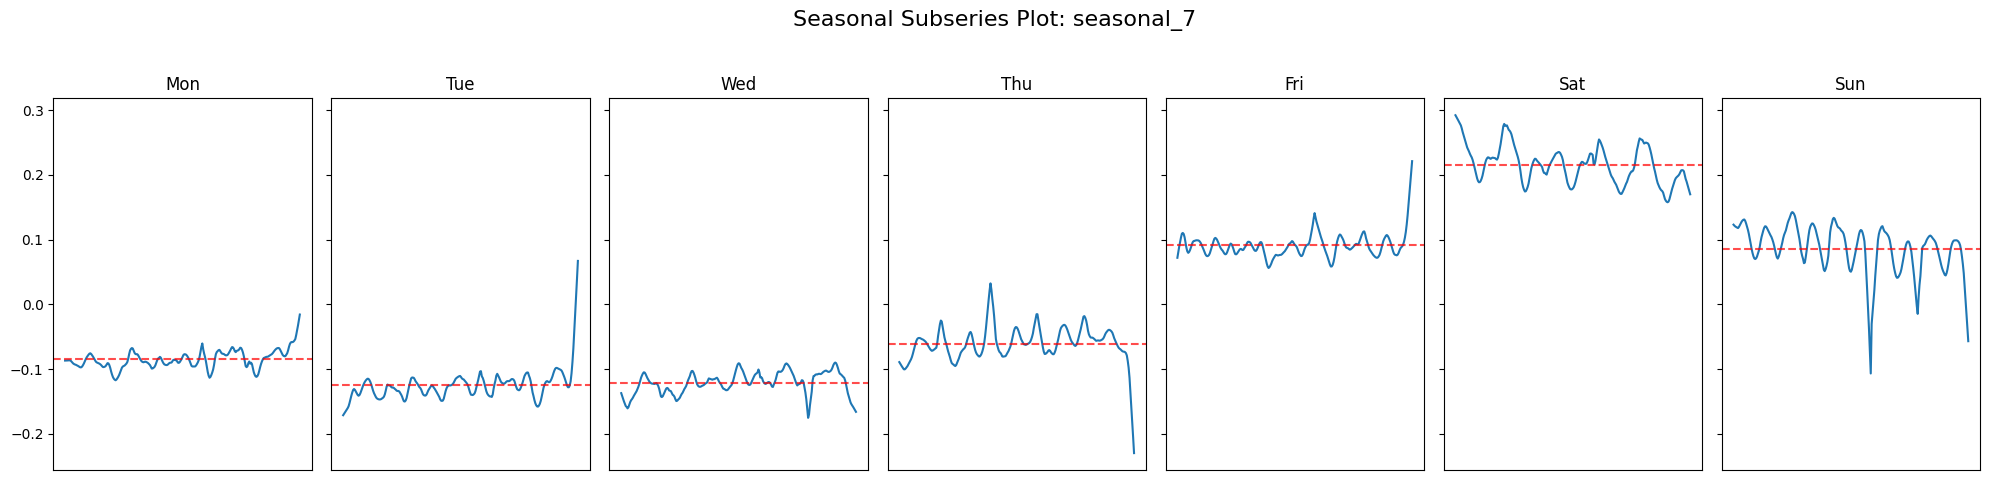

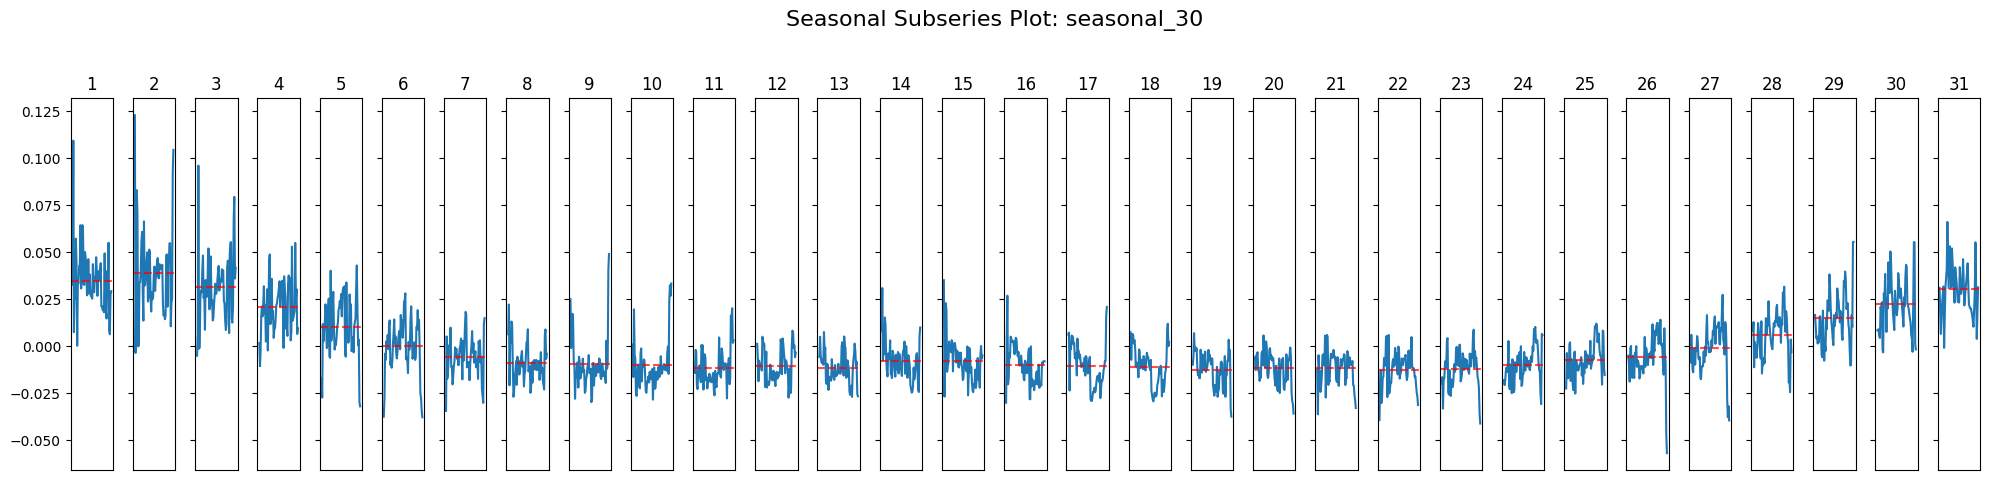

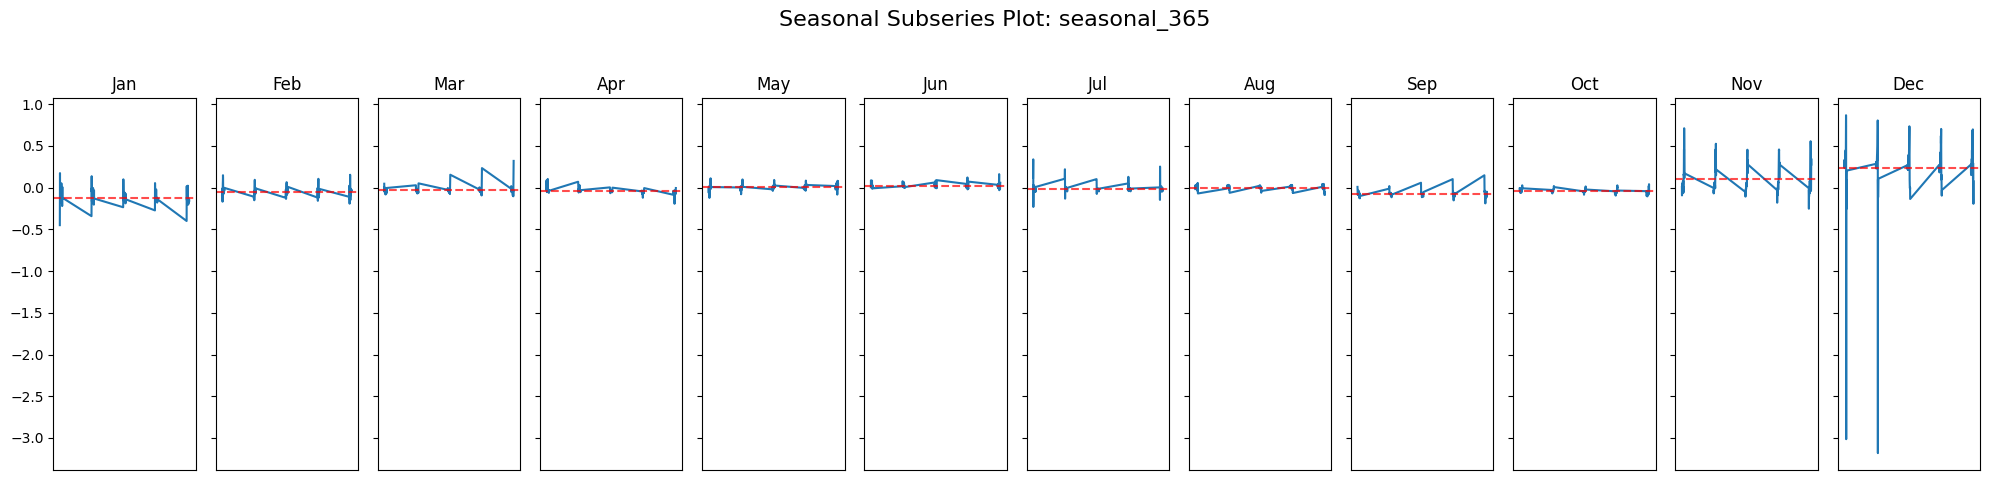

In [185]:
def plot_seasonal_subseries(res, period_name, group_by_feature):
    """
    Plots the seasonal subseries for a specific MSTL component.
    group_by_feature: 'dayofweek', 'day', or 'month'
    """
    # Extract the specific seasonal component
    comp = res.seasonal[period_name]
    
    # Create a grouping variable based on the index
    if group_by_feature == 'dayofweek':
        groups = comp.index.dayofweek
        labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    elif group_by_feature == 'day':
        groups = comp.index.day
        labels = [str(i) for i in range(1, 32)]
    elif group_by_feature == 'month':
        groups = comp.index.month
        labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    unique_groups = sorted(groups.unique())
    
    fig, axes = plt.subplots(1, len(unique_groups), figsize=(20, 5), sharey=True)
    fig.suptitle(f'Seasonal Subseries Plot: {period_name}', fontsize=16)
    
    for i, g in enumerate(unique_groups):
        subset = comp[groups == g]
        axes[i].plot(subset.index, subset.values)
        axes[i].axhline(subset.mean(), color='red', linestyle='--', alpha=0.7)
        axes[i].set_title(labels[i] if i < len(labels) else g)
        axes[i].tick_params(axis='x', rotation=45)
        # Remove x-labels to keep it clean
        axes[i].set_xticks([]) 

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- Execution ---
# 1. Weekly Subseries (Are Mondays changing over time?)
plot_seasonal_subseries(res, 'seasonal_7', 'dayofweek')

# 2. Monthly Subseries (Is the 'start of month' spike stable?)
plot_seasonal_subseries(res, 'seasonal_30', 'day')

# 3. Yearly Subseries (How has the 'December' effect evolved across the decade?)
plot_seasonal_subseries(res, 'seasonal_365', 'month')

### S3 Last

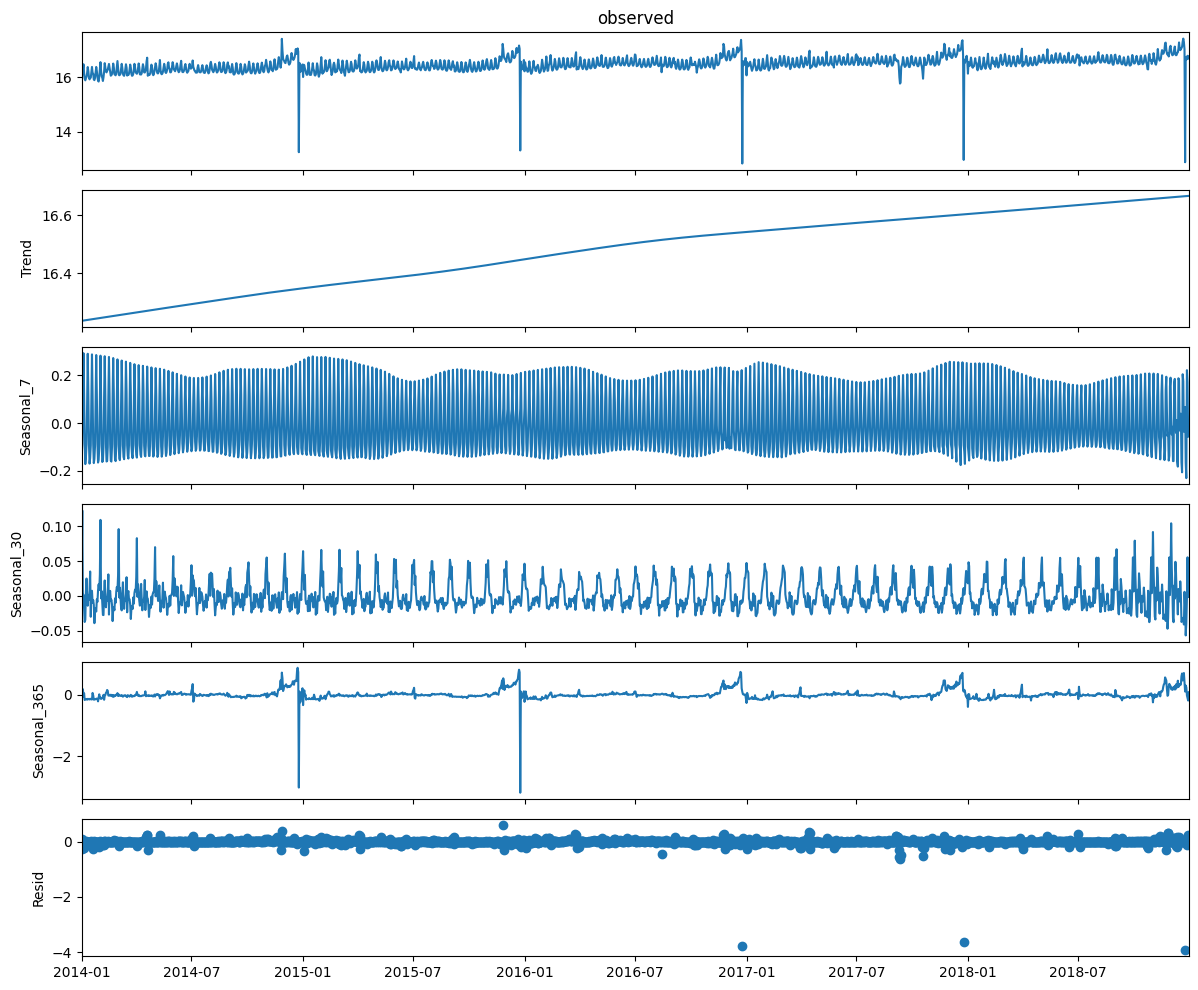

In [186]:
log_s3_ts = np.log(train_s3_ts.copy())

series = log_s3_ts['S3']
series.index = pd.to_datetime(series.index)
series = series.asfreq('D') 

res = MSTL(
    series,                                         
    periods=(7, 30, 365),                           # Seasonal periods: weekly and monthly
    stl_kwargs={
        "seasonal": (31, 61, 1001), 
        "robust": True
        }
).fit()

fig = res.plot()
fig.set_size_inches(12, 10)
plt.tight_layout()
plt.show()

## Autocorrelation

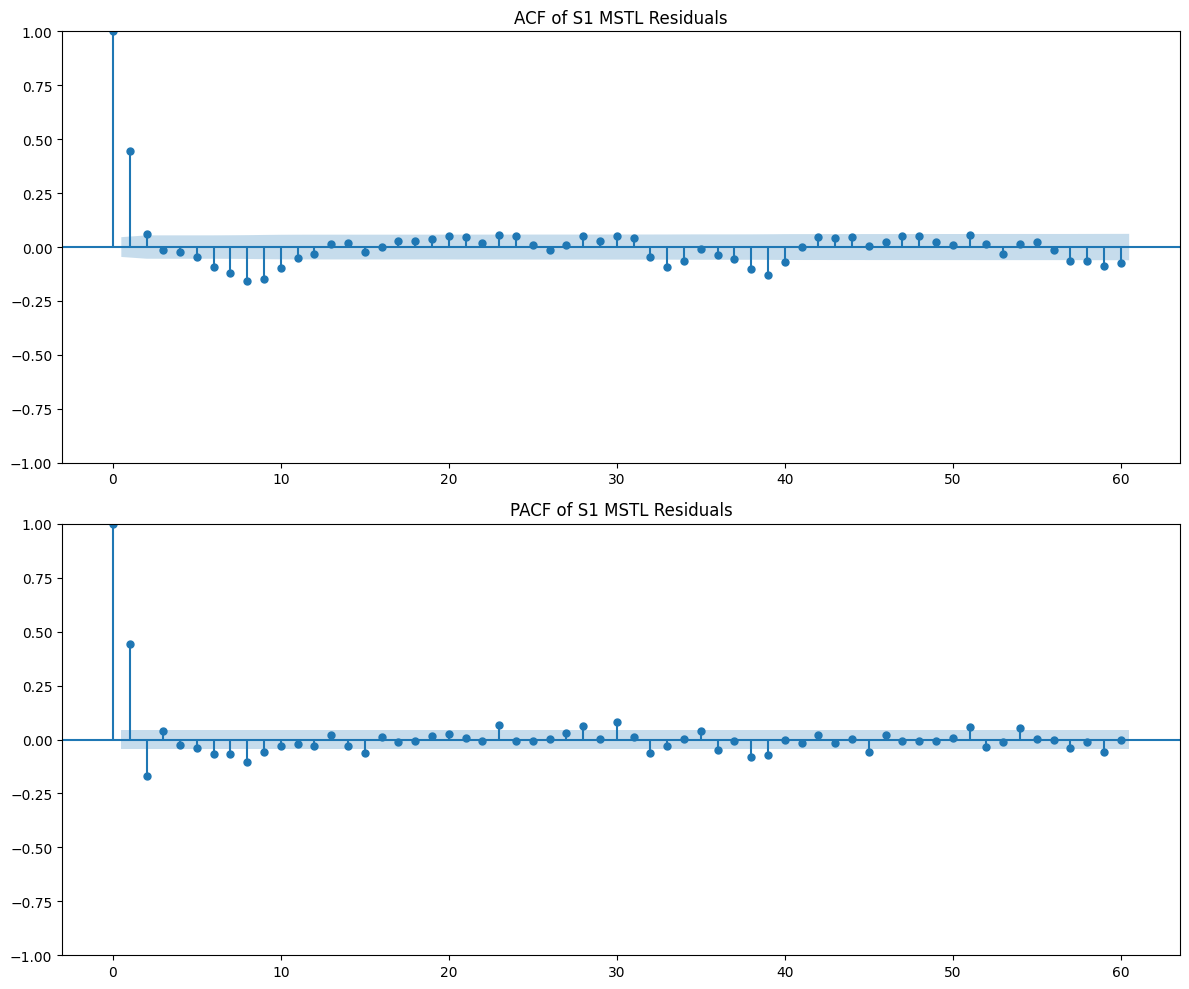

In [187]:
log_s1_ts = np.log(train_s1_ts.copy())

series = log_s1_ts['S1']
series.index = pd.to_datetime(series.index)
series = series.asfreq('D') 

res = MSTL(
    series,                                         # 
    periods=(7, 30),                                # Seasonal periods: weekly and monthly
    stl_kwargs={"seasonal": 31, "robust": True}     #
).fit()

# 1. Extract residuals from your existing 'res' object
# Dropping NaNs if any were introduced during interpolation/processing
residuals = res.resid.dropna()

# 2. Plot ACF and PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# ACF shows the correlation between the series and its lags
plot_acf(residuals, lags=60, ax=ax1, title='ACF of S1 MSTL Residuals')

# PACF shows the direct correlation after removing intermediate lag effects
plot_pacf(residuals, lags=60, ax=ax2, title='PACF of S1 MSTL Residuals')

plt.tight_layout()
plt.show()

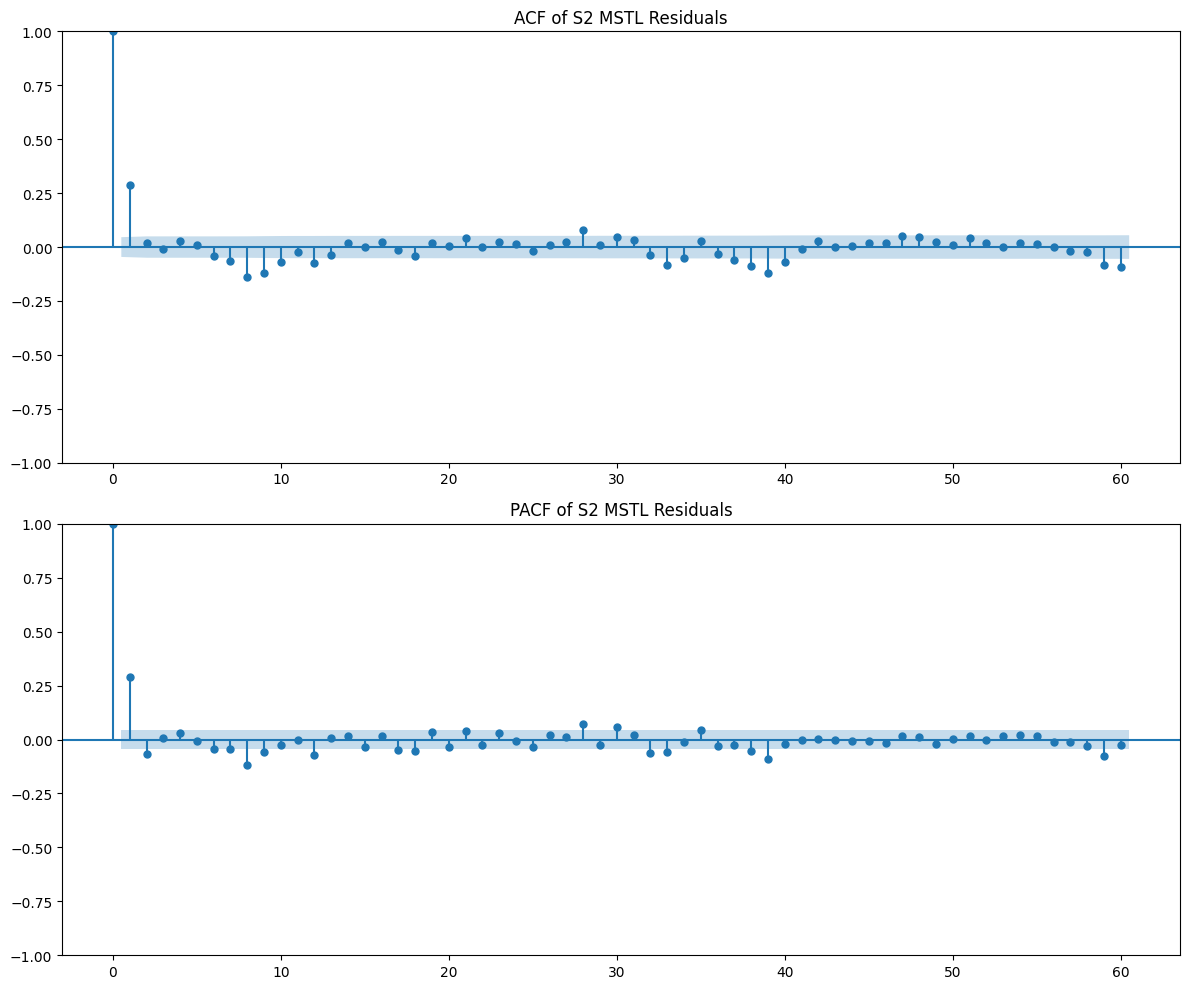

In [188]:
log_s2_ts = np.log(train_s2_ts.copy())

series = log_s2_ts['S2']
series.index = pd.to_datetime(series.index)
series = series.asfreq('D') 

res = MSTL(
    series,                                         # 
    periods=(7, 30),                                # Seasonal periods: weekly and monthly
    stl_kwargs={"seasonal": 31, "robust": True}     #
).fit()

# 1. Extract residuals from your existing 'res' object
# Dropping NaNs if any were introduced during interpolation/processing
residuals = res.resid.dropna()

# 2. Plot ACF and PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# ACF shows the correlation between the series and its lags
plot_acf(residuals, lags=60, ax=ax1, title='ACF of S2 MSTL Residuals')

# PACF shows the direct correlation after removing intermediate lag effects
plot_pacf(residuals, lags=60, ax=ax2, title='PACF of S2 MSTL Residuals')

plt.tight_layout()
plt.show()

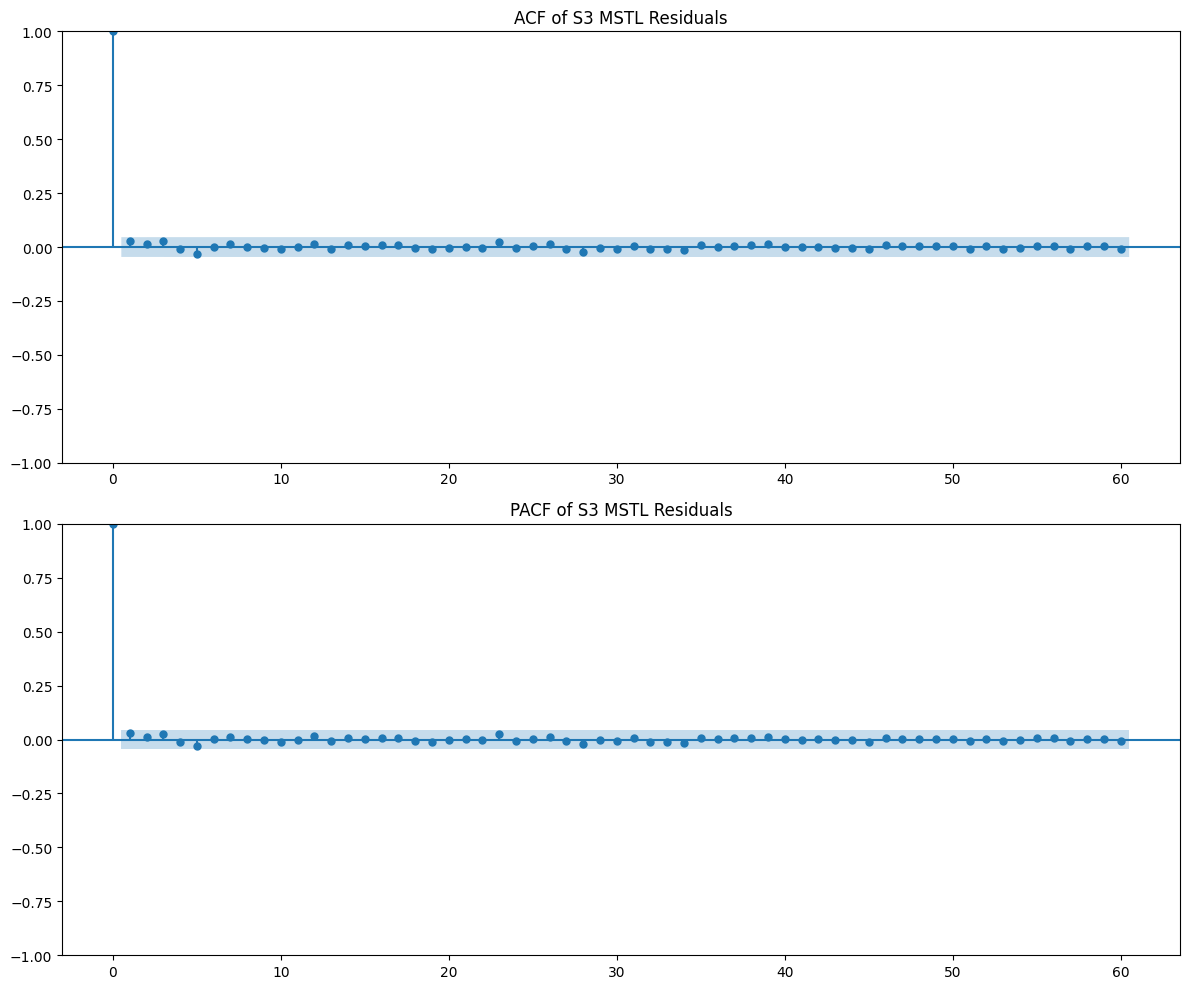

In [189]:
log_s3_ts = np.log(train_s3_ts.copy())

series = log_s3_ts['S3']
series.index = pd.to_datetime(series.index)
series = series.asfreq('D') 

res = MSTL(
    series,                                         
    periods=(7, 30, 365),                           # Seasonal periods: weekly and monthly
    stl_kwargs={
        "seasonal": (31, 61, 1001), 
        "robust": True
        }
).fit()

# 1. Extract residuals from your existing 'res' object
# Dropping NaNs if any were introduced during interpolation/processing
residuals = res.resid.dropna()

# 2. Plot ACF and PACF
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# ACF shows the correlation between the series and its lags
plot_acf(residuals, lags=60, ax=ax1, title='ACF of S3 MSTL Residuals')

# PACF shows the direct correlation after removing intermediate lag effects
plot_pacf(residuals, lags=60, ax=ax2, title='PACF of S3 MSTL Residuals')

plt.tight_layout()
plt.show()

## 2. Forecasting

Intuitive ExplanationThis function forecasts by averaging values from the same position in multiple seasonal cycles. It's a multi-seasonal extension of the classic seasonal naive method.

In [154]:
def walk_forward_seasonal_naive(train_series, val_series, periods):
    """
    Naive walk-forward: Use last observation + seasonal pattern
    No decomposition needed - just replicate seasonal cycles
    """
    predictions = []
    n_train = len(train_series)
    full_series = pd.concat([train_series, val_series])
    
    for t in range(len(val_series)):
        # For each seasonal period, look back and take that value
        # Average across all periods for stability
        lookbacks = []
        for p in periods:
            if n_train + t >= p:
                lookbacks.append(full_series.iloc[n_train + t - p])
        
        # Simple average of seasonal lookbacks
        predictions.append(np.mean(lookbacks) if lookbacks else train_series.iloc[-1])
    
    return pd.Series(predictions, index=val_series.index)

series_names = ['S1', 'S2', 'S3']
seasonal_config = {
    'S1': (7, 30),
    'S2': (7, 30),
    'S3': (7, 30, 365)
}
results = []

for i, col_name in enumerate(series_names):
    train = train_tss[i][col_name]
    val = test_tss[i][col_name]
    periods = seasonal_config[col_name]
    
    # 1. Simple Naive (One-step shift)
    # The simplest baseline: today = yesterday
    simple_pred = val.shift(1).fillna(train.iloc[-1])
    mse_simple = mean_squared_error(val, simple_pred)
    
    # 2. Walk-Forward Multi-Seasonal
    wf_multi_pred = walk_forward_seasonal_naive(train, val, periods)
    mse_multi = mean_squared_error(val, wf_multi_pred)
    
    results.append({
        'Series': col_name,
        'Config': str(periods),
        'Simple Naive MSE': f"{mse_simple:,.2e}",
        'WF Multi-Seasonal MSE': f"{mse_multi:,.2e}",
        'Improvement %': f"{((mse_simple - mse_multi) / mse_simple) * 100:.2f}%"
    })

print(pd.DataFrame(results).to_markdown(index=False))

| Series   | Config       |   Simple Naive MSE |   WF Multi-Seasonal MSE | Improvement %   |
|:---------|:-------------|-------------------:|------------------------:|:----------------|
| S1       | (7, 30)      |           1.67e+11 |                8.13e+10 | 51.42%          |
| S2       | (7, 30)      |           2.44e+11 |                9.51e+10 | 60.99%          |
| S3       | (7, 30, 365) |           1.05e+13 |                9.44e+12 | 9.73%           |


In [164]:
def walk_forward_linear_regression(train_series, val_series, periods):
    """
    Estimates a Linear Regression with AR and Seasonal lags in a walk-forward manner.
    """
    # 1. Prepare data in log space
    full_series = pd.concat([np.log(train_series), np.log(val_series)])
    n_train = len(train_series)
    n_val = len(val_series)
    
    # We need a 'max_lag' to build the feature matrix
    max_lag = max(periods) if periods else 1
    
    predictions = []
    
    # Walk-forward through the validation set
    for t in range(n_val):
        curr_idx = n_train + t
        
        # Build training features (all data available up to t)
        # Using a rolling window of the last 365 days for parameter estimation
        # prevents the model from being biased by very old data (2014)
        lookback_window = 365 
        train_start = max(max_lag, curr_idx - lookback_window)
        
        y_train = full_series.iloc[train_start:curr_idx]
        X_train = []
        
        for i in range(train_start, curr_idx):
            # Features: AR(1) and Seasonal Lags
            features = [full_series.iloc[i-1]] # Lag 1
            for p in periods:
                features.append(full_series.iloc[i-p])
            X_train.append(features)
        
        # Fit Model
        model = LinearRegression()
        model.fit(X_train, y_train)
        
        # Predict one step ahead
        X_next = [full_series.iloc[curr_idx-1]] # Today's value for tomorrow
        for p in periods:
            X_next.append(full_series.iloc[curr_idx-p])
            
        y_hat_log = model.predict([X_next])[0]
        predictions.append(np.exp(y_hat_log))
        
    return pd.Series(predictions, index=val_series.index)

series_names = ['S1', 'S2', 'S3']
seasonal_config = {'S1': (7, 30), 'S2': (7, 30), 'S3': (7, 30, 365)}
results = []

for i, col_name in enumerate(series_names):
    train, val = train_tss[i][col_name], test_tss[i][col_name]
    periods = seasonal_config[col_name]
    
    # 1. Simple Naive (Today = Yesterday)
    simple_pred = val.shift(1).fillna(train.iloc[-1])
    mse_simple = mean_squared_error(val, simple_pred)
    
    # 2. WF Seasonal Naive (Heuristic)
    wf_naive_pred = walk_forward_seasonal_naive(train, val, periods)
    mse_wf_naive = mean_squared_error(val, wf_naive_pred)
    
    # 3. WF Linear Regression (Optimized)
    lr_pred = walk_forward_linear_regression(train, val, periods)
    mse_lr = mean_squared_error(val, lr_pred)
    
    results.append({
        'Series': col_name,
        'Simple Naive MSE': f"{mse_simple:,.2e}",
        'WF Seasonal Naive MSE': f"{mse_wf_naive:,.2e}",
        'Linear Regression MSE': f"{mse_lr:,.2e}",
        'vs Simple Naive %': f"{((mse_simple - mse_lr) / mse_simple) * 100:.2f}%",
        'vs WF Seasonal Naive %': f"{((mse_wf_naive - mse_lr) / mse_wf_naive) * 100:.2f}%"
    })

print(pd.DataFrame(results).to_markdown(index=False))

| Series   |   Simple Naive MSE |   WF Seasonal Naive MSE |   Linear Regression MSE | vs Simple Naive %   | vs WF Seasonal Naive %   |
|:---------|-------------------:|------------------------:|------------------------:|:--------------------|:-------------------------|
| S1       |           1.67e+11 |                8.13e+10 |                3.87e+10 | 76.88%              | 52.41%                   |
| S2       |           2.44e+11 |                9.51e+10 |                4.35e+10 | 82.14%              | 54.23%                   |
| S3       |           1.05e+13 |                9.44e+12 |                6.3e+12  | 39.78%              | 33.29%                   |


- Because MSE squares the error, it is obsessed with the outliers.
- MAPE treats a "miss" more linearly, making it more representative of typical performance.
- Because OLS minimizes squared distances, those deep downward spikes act like magnets. They pull the regression line down, causing your model to systematically under-forecast the growth trend.
- By minimizing the Mean Absolute Error (MAE), the model ignores the magnitude of extreme outliers and only cares about their direction. It stays locked on the "Median" path of the data.


Heuristic for interpreting MAPE is as follows:

- < 10%: Highly accurate forecasting.
- 10% - 20%: Good forecasting.
- 20% - 50%: Reasonable forecasting.
- 50%: Inaccurate forecasting.

In [168]:
def walk_forward_quantile_regression(train_series, val_series, periods):
    # Log-transform to handle multiplicative variance
    full_series = pd.concat([np.log(train_series), np.log(val_series)])
    n_train, n_val = len(train_series), len(val_series)
    max_lag = max(periods)
    predictions = []
    
    for t in range(n_val):
        curr_idx = n_train + t
        # Using a shorter 1-year window to keep QuantileRegressor efficient
        lookback_window = 365 
        train_start = max(max_lag, curr_idx - lookback_window)
        
        y_train = full_series.iloc[train_start:curr_idx]
        X_train = []
        for i in range(train_start, curr_idx):
            features = [full_series.iloc[i-1]] + [full_series.iloc[i-p] for p in periods]
            X_train.append(features)
        
        # alpha=0 means no regularization; quantile=0.5 is the Median (MAE loss)
        model = QuantileRegressor(quantile=0.5, alpha=0, solver='highs')
        model.fit(X_train, y_train)
        
        X_next = [full_series.iloc[curr_idx-1]] + [full_series.iloc[curr_idx-p] for p in periods]
        y_hat_log = model.predict([X_next])[0]
        predictions.append(np.exp(y_hat_log))
        
    return pd.Series(predictions, index=val_series.index)

# --- Updated Loop ---
series_names = ['S1', 'S2', 'S3']
seasonal_config = {'S1': (7, 30), 'S2': (7, 30), 'S3': (7, 30, 365)}
results = []

for i, col_name in enumerate(series_names):
    train, val = train_tss[i][col_name], test_tss[i][col_name]
    periods = seasonal_config[col_name]
    
    # 1. Simple Naive
    simple_pred = val.shift(1).fillna(train.iloc[-1])
    mape_simple = mean_absolute_percentage_error(val, simple_pred)
    
    # 2. WF Seasonal Naive
    wf_naive_pred = walk_forward_seasonal_naive(train, val, periods)
    mape_wf_naive = mean_absolute_percentage_error(val, wf_naive_pred)
    
    # 3. OLS Linear Regression
    lr_pred = walk_forward_linear_regression(train, val, periods)
    mape_lr = mean_absolute_percentage_error(val, lr_pred)
    
    # 4. Quantile Regression (MAE/Median)
    qr_pred = walk_forward_quantile_regression(train, val, periods)
    mape_qr = mean_absolute_percentage_error(val, qr_pred)
    
    results.append({
        'Series': col_name,
        'Simple Naive': f"{mape_simple:.2%}",
        'S-Naive': f"{mape_wf_naive:.2%}",
        'OLS (MSE)': f"{mape_lr:.2%}",
        'Quantile (MAE)': f"{mape_qr:.2%}",
        'Best Improv vs Naive': f"{(mape_simple - min(mape_lr, mape_qr)):.2%}"
    })

print(pd.DataFrame(results).to_markdown(index=False))

| Series   | Simple Naive   | S-Naive   | OLS (MSE)   | Quantile (MAE)   | Best Improv vs Naive   |
|:---------|:---------------|:----------|:------------|:-----------------|:-----------------------|
| S1       | 27.59%         | 22.28%    | 12.46%      | 12.09%           | 15.50%                 |
| S2       | 30.00%         | 21.47%    | 12.24%      | 12.03%           | 17.97%                 |
| S3       | 26.82%         | 19.68%    | 9.22%       | 9.32%            | 17.60%                 |


In [169]:

def walk_forward_quantile_regression(train_series, val_series, periods):
    full_series = pd.concat([np.log(train_series), np.log(val_series)])
    n_train, n_val = len(train_series), len(val_series)
    max_lag = max(max(periods), 3)
    predictions = []
    
    for t in range(n_val):
        curr_idx = n_train + t
        lookback_window = 365 
        train_start = max(max_lag, curr_idx - lookback_window)
        
        y_train = full_series.iloc[train_start:curr_idx]
        X_train = []
        for i in range(train_start, curr_idx):
            # Features: Lag 1, 2, 3 + Seasonal Lags
            features = [full_series.iloc[i-1], full_series.iloc[i-2], full_series.iloc[i-3]] 
            features += [full_series.iloc[i-p] for p in periods]
            X_train.append(features)
        
        model = QuantileRegressor(quantile=0.5, alpha=0, solver='highs')
        model.fit(X_train, y_train)
        
        X_next = [full_series.iloc[curr_idx-1], full_series.iloc[curr_idx-2], full_series.iloc[curr_idx-3]]
        X_next += [full_series.iloc[curr_idx-p] for p in periods]
        
        y_hat_log = model.predict([X_next])[0]
        predictions.append(np.exp(y_hat_log))
        
    return pd.Series(predictions, index=val_series.index)

def walk_forward_linear_regression(train_series, val_series, periods):
    full_series = pd.concat([np.log(train_series), np.log(val_series)])
    n_train, n_val = len(train_series), len(val_series)
    max_lag = max(max(periods), 3) if periods else 3
    predictions = []
    
    for t in range(n_val):
        curr_idx = n_train + t
        lookback_window = 365 
        train_start = max(max_lag, curr_idx - lookback_window)
        
        y_train = full_series.iloc[train_start:curr_idx]
        X_train = []
        for i in range(train_start, curr_idx):
            # Features: Lag 1, 2, 3 + Seasonal Lags
            features = [full_series.iloc[i-1], full_series.iloc[i-2], full_series.iloc[i-3]]
            features += [full_series.iloc[i-p] for p in periods]
            X_train.append(features)
        
        model = LinearRegression().fit(X_train, y_train)
        
        X_next = [full_series.iloc[curr_idx-1], full_series.iloc[curr_idx-2], full_series.iloc[curr_idx-3]]
        X_next += [full_series.iloc[curr_idx-p] for p in periods]
            
        y_hat_log = model.predict([X_next])[0]
        predictions.append(np.exp(y_hat_log))
        
    return pd.Series(predictions, index=val_series.index)

# --- Updated Loop ---
series_names = ['S1', 'S2', 'S3']
seasonal_config = {'S1': (7, 30), 'S2': (7, 30), 'S3': (7, 30, 365)}
results = []

for i, col_name in enumerate(series_names):
    train, val = train_tss[i][col_name], test_tss[i][col_name]
    periods = seasonal_config[col_name]
    
    # 1. Simple Naive
    simple_pred = val.shift(1).fillna(train.iloc[-1])
    mape_simple = mean_absolute_percentage_error(val, simple_pred)
    
    # 2. WF Seasonal Naive
    wf_naive_pred = walk_forward_seasonal_naive(train, val, periods)
    mape_wf_naive = mean_absolute_percentage_error(val, wf_naive_pred)
    
    # 3. OLS Linear Regression
    lr_pred = walk_forward_linear_regression(train, val, periods)
    mape_lr = mean_absolute_percentage_error(val, lr_pred)
    
    # 4. Quantile Regression (MAE/Median)
    qr_pred = walk_forward_quantile_regression(train, val, periods)
    mape_qr = mean_absolute_percentage_error(val, qr_pred)
    
    results.append({
        'Series': col_name,
        'Simple Naive': f"{mape_simple:.2%}",
        'S-Naive': f"{mape_wf_naive:.2%}",
        'OLS (MSE)': f"{mape_lr:.2%}",
        'Quantile (MAE)': f"{mape_qr:.2%}",
        'Best Improv vs Naive': f"{(mape_simple - min(mape_lr, mape_qr)):.2%}"
    })

print(pd.DataFrame(results).to_markdown(index=False))

| Series   | Simple Naive   | S-Naive   | OLS (MSE)   | Quantile (MAE)   | Best Improv vs Naive   |
|:---------|:---------------|:----------|:------------|:-----------------|:-----------------------|
| S1       | 27.59%         | 22.28%    | 12.41%      | 12.11%           | 15.49%                 |
| S2       | 30.00%         | 21.47%    | 12.23%      | 11.97%           | 18.03%                 |
| S3       | 26.82%         | 19.68%    | 8.81%       | 8.86%            | 18.01%                 |
